In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
!pip install dagshub
!pip install mlflow

  Using cached mlflow-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_skinny-3.11.1-py3-none-any.whl.metadata (49 kB)
  Using cached mlflow_tracing-3.11.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached gunicorn-25.3.0-py3-none-any.whl.metadata (5.5 kB)
  Using cached huey-2.6.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached skops-0.14.0-py3-none-any.whl.metadata (4.4 kB)
  Using cached databricks_sdk-0.106.0-py3-none-any.whl.metadata (43 kB)
  Using cached graphql_relay-3.2.0-py3-none-any.whl.metadata (12 kB)
Using cached mlflow-3.11.1-py3-none-any.whl (10.5 MB)
Using cached mlflow_skinny-3.11.1-py3-none-any.whl (3.2 MB)
Using cached mlflow_tracing-3.11.1-py3-none-any.whl (1.6 MB)
Using cached flask_cors-6.0.2-py3-none-any.whl (13 kB)
Using cached graphene-3.4.3-py2.py3-none-any.whl (114 kB)
Using cached gunicorn-25.3.0-py3-none-any

In [4]:
import dagshub
import mlflow
dagshub.init(repo_owner='mkekn23', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d1775eeb-8def-47bc-98a5-2c8480b6aedc&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=bae322b9a1c7c7de895f1c2612a444f786b0b71c8ee6983d8ce7030e54eabbd9




Accessing as mkekn23

Initialized MLflow to track repo "mkekn23/IEEE-CIS-Fraud-Detection"

Repository mkekn23/IEEE-CIS-Fraud-Detection initialized!

# Cleaning

In [8]:
df_identity= pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv")
df_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')

In [9]:
df_identity.head()
df_identity.shape

(144233, 41)

In [10]:
df_transaction.head()
df_transaction.shape

(590540, 394)

In [11]:
df.head()
df.shape

(590540, 434)

In [14]:
del df_transaction, df_identity

NameError: name 'df_transaction' is not defined

In [16]:
import numpy as np

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage of dataframe is {start_mem:.2f} MB')
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage after optimization is: {end_mem:.2f} MB')
    print(f'Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%')
    
    return df

train test split: 

In [17]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

X = reduce_mem_usage(X)
# y-ს ხელით ვაქცევთ ყველაზე პატარა ტიპად (რადგან მხოლოდ 0/1-ია)
y = y.astype('int8') 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Memory usage of dataframe is 1950.87 MB


/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/265391772.py:24: RuntimeWarning: overflow enco

Memory usage after optimization is: 524.99 MB
Decreased by 73.1%


In [18]:
X_train.info

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


<bound method DataFrame.info of         TransactionID  TransactionDT  TransactionAmt ProductCD  card1  card2  \
5307          2992307         174911         59.0000         W   4988  334.0   
191582        3178582        4301977         23.3750         C   3867  296.0   
260168        3247168        6229929         35.9375         W  12577  268.0   
18516         3005516         497176        100.0000         R   6019  583.0   
47538         3034538        1124702         75.0000         H  16075  514.0   
...               ...            ...             ...       ...    ...    ...   
110268        3097268        2157580         25.0000         H  16796  555.0   
259178        3246178        6213562        358.0000         W  16727  111.0   
365838        3352838        9076295        156.0000         W   3283  555.0   
131932        3118932        2614452         59.0000         W   9500  321.0   
121958        3108958        2399529         44.0000         W  10616  583.0   

       

Top 10 columns with most NaN values:
V1     0.472832
V2     0.472832
V3     0.472832
V4     0.472832
V5     0.472832
V6     0.472832
V7     0.472832
V8     0.472832
V9     0.472832
V10    0.472832
dtype: float64


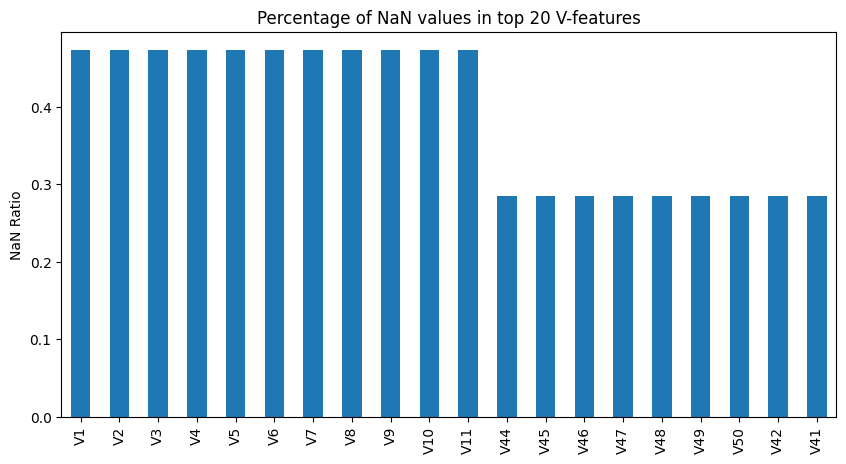

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
v_cols = [c for c in X_train.columns if c.startswith('V')][:50]
v_subset = X_train[v_cols]

nan_stats = v_subset.isnull().mean().sort_values(ascending=False)
print("Top 10 columns with most NaN values:")
print(nan_stats.head(10))

# დავხატოთ გრაფიკი
nan_stats.head(20).plot(kind='bar', figsize=(10, 5))
plt.title('Percentage of NaN values in top 20 V-features')
plt.ylabel('NaN Ratio')
plt.show()

Top 10 Identity columns with most NaN values:
id_24    0.991933
id_25    0.991292
id_08    0.991250
id_07    0.991250
id_21    0.991241
id_26    0.991239
id_27    0.991226
id_22    0.991226
id_23    0.991226
id_18    0.923574
dtype: float64


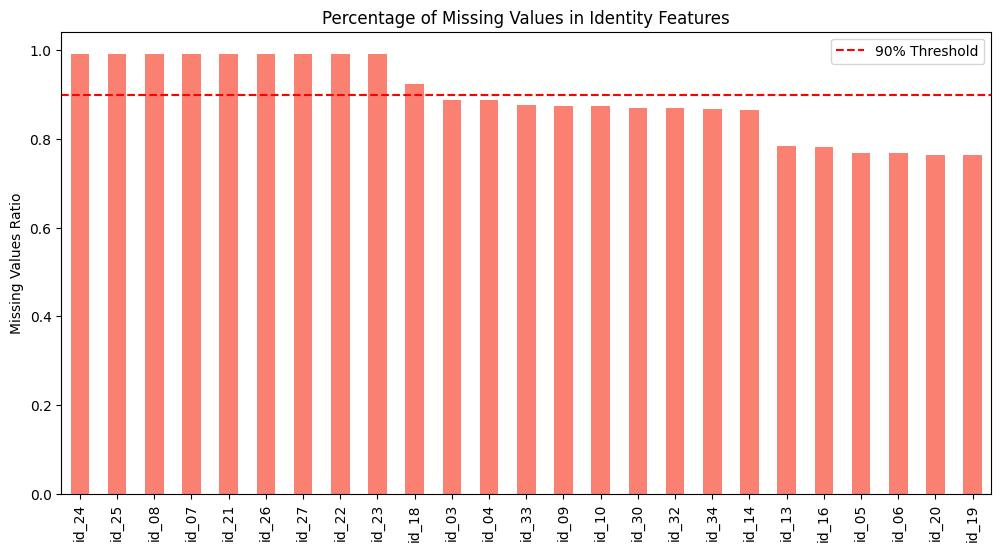

In [20]:

id_cols = [c for c in X_train.columns if c.startswith('id_')]
id_subset = X_train[id_cols]


id_nan_stats = id_subset.isnull().mean().sort_values(ascending=False)


print("Top 10 Identity columns with most NaN values:")
print(id_nan_stats.head(10))


plt.figure(figsize=(12, 6))
id_nan_stats.head(25).plot(kind='bar', color='salmon')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold') # წითელი ხაზი 90%-ზე
plt.title('Percentage of Missing Values in Identity Features')
plt.ylabel('Missing Values Ratio')
plt.legend()
plt.show()

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

class DropMissingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_drop = []

    def fit(self, X, y=None):
        nan_ratio = X.isnull().mean()
        self.features_to_drop = nan_ratio[nan_ratio > self.threshold].index.tolist()
        return self

    def transform(self, X):
        return X.drop(columns=self.features_to_drop)

In [22]:
dropper = DropMissingFeatures(threshold=0.9)

dropper.fit(X_train)

print(f"წასაშლელი სვეტების რაოდენობა: {len(dropper.features_to_drop)}")
print(f"ეს სვეტებია: {dropper.features_to_drop}")

X_train_cleaned = dropper.transform(X_train)

print(f"ორიგინალი სვეტები: {X_train.shape[1]}")
print(f"დარჩენილი სვეტები: {X_train_cleaned.shape[1]}")

წასაშლელი სვეტების რაოდენობა: 12
ეს სვეტებია: ['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']
ორიგინალი სვეტები: 433
დარჩენილი სვეტები: 421


In [23]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# numerical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# category columns
cat_cols = X_train.select_dtypes(include=['object']).columns

imputer = ColumnTransformer(transformers=[
    ('num_imputer', SimpleImputer(strategy='median'), num_cols),
    ('cat_imputer', SimpleImputer(strategy='most_frequent'), cat_cols)
])

# Feature Engineering

In [58]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import numpy as np

class CategoricalEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        self.cat_cols = None

    def fit(self, X, y=None):
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        
        if self.cat_cols:
            temp_df = X[self.cat_cols].copy()
            for col in self.cat_cols:
                if hasattr(temp_df[col], 'cat'):
                    if 'Unknown' not in temp_df[col].cat.categories:
                        temp_df[col] = temp_df[col].cat.add_categories(['Unknown'])
            temp_df = temp_df.fillna('Unknown').astype(str) # ყველაფერს ვაქცევთ სტრინგად
            self.encoder.fit(temp_df)
        return self


    def transform(self, X):
        X_out = X.copy()
        if self.cat_cols:
            temp_df = X_out[self.cat_cols].copy()
            for col in self.cat_cols:
                if hasattr(temp_df[col], 'cat'):
                    if 'Unknown' not in temp_df[col].cat.categories:
                        temp_df[col] = temp_df[col].cat.add_categories(['Unknown'])
            temp_df = temp_df.fillna('Unknown').astype(str)
            X_out[self.cat_cols] = self.encoder.transform(temp_df)
        return X_out

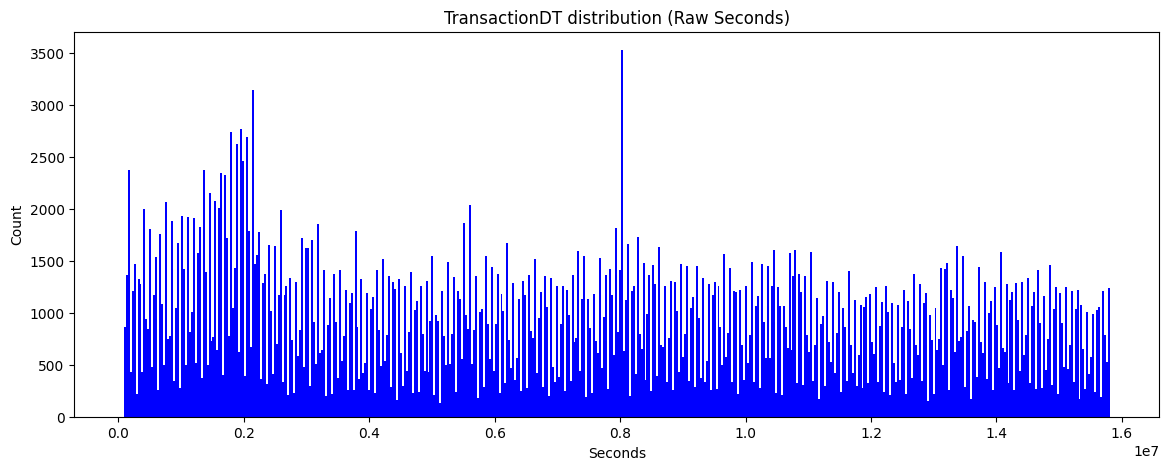

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
# დავხატავთ ტრანზაქციების განაწილებას დროში
X_train['TransactionDT'].plot(kind='hist', bins=500, color='blue')
plt.title('TransactionDT distribution (Raw Seconds)')
plt.xlabel('Seconds')
plt.ylabel('Count')
plt.show()

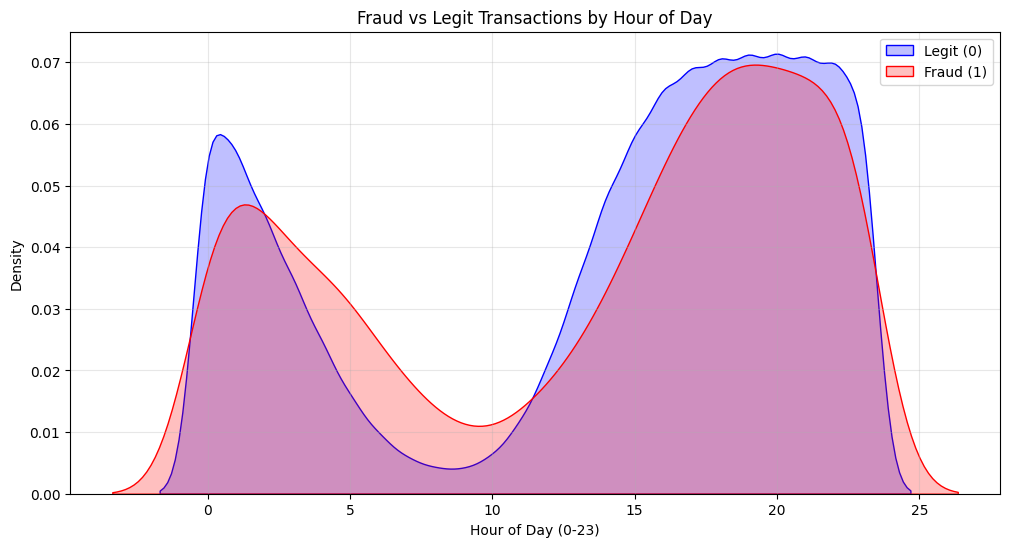

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# დროებითი DataFrame ვიზუალიზაციისთვის
temp_df = pd.DataFrame({
    'TransactionDT': X_train['TransactionDT'],
    'isFraud': y_train
})

# საათის გამოთვლა (0-23)
temp_df['hour'] = (temp_df['TransactionDT'] // 3600) % 24

plt.figure(figsize=(12, 6))
# დავხატოთ სიმკვრივის გრაფიკი
sns.kdeplot(temp_df[temp_df['isFraud'] == 0]['hour'], label='Legit (0)', fill=True, color="blue")
sns.kdeplot(temp_df[temp_df['isFraud'] == 1]['hour'], label='Fraud (1)', fill=True, color="red")

plt.title('Fraud vs Legit Transactions by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

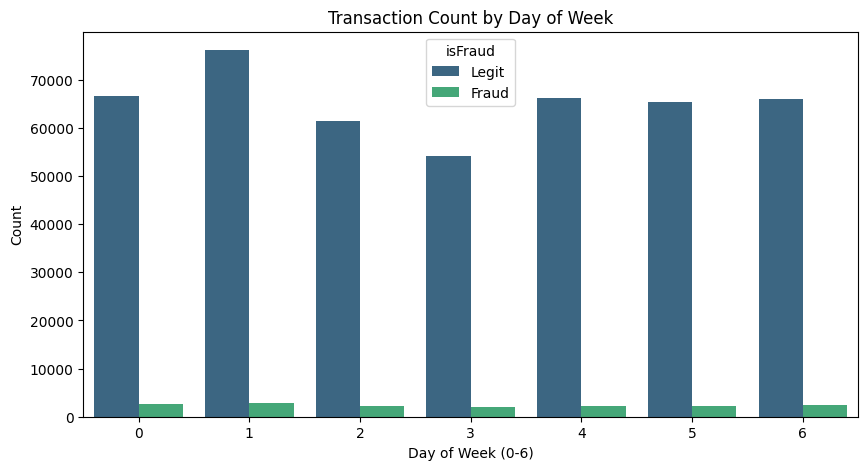

In [29]:
# კვირის დღის გამოთვლა
temp_df['dow'] = (temp_df['TransactionDT'] // (3600 * 24)) % 7

plt.figure(figsize=(10, 5))
sns.countplot(data=temp_df, x='dow', hue='isFraud', palette='viridis')
plt.title('Transaction Count by Day of Week')
plt.xlabel('Day of Week (0-6)')
plt.ylabel('Count')
plt.legend(title='isFraud', labels=['Legit', 'Fraud'])
plt.show()

In [31]:
class TimeFeaturesEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_copy = X.copy()
     
        X_copy['hour'] = (X_copy['TransactionDT'] // 3600) % 24
        X_copy['dow'] = (X_copy['TransactionDT'] // (3600 * 24)) % 7
        return X_copy

In [70]:
from sklearn.base import BaseEstimator, TransformerMixin

class GroupAggregationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, groups=['card1', 'addr1']):
        self.groups = groups
        self.stats = {}

    def fit(self, X, y=None):
        for group in self.groups:
            temp_X = X[[group, 'TransactionAmt']].astype({group: 'float32', 'TransactionAmt': 'float32'}, errors='ignore')
            
            self.stats[group] = temp_X.groupby(group)['TransactionAmt'].agg(['mean', 'std']).to_dict()
        return self

    def transform(self, X):
        X_out = X.copy()
        for group in self.groups:
            # აქაც float32-ში გადაყვანა უსაფრთხოებისთვის
            group_val = X_out[group].astype('float32', errors='ignore')
            
            X_out[f'{group}_amt_mean'] = group_val.map(self.stats[group]['mean'])
            X_out[f'{group}_amt_std'] = group_val.map(self.stats[group]['std'])
        return X_out

# Feature Selection

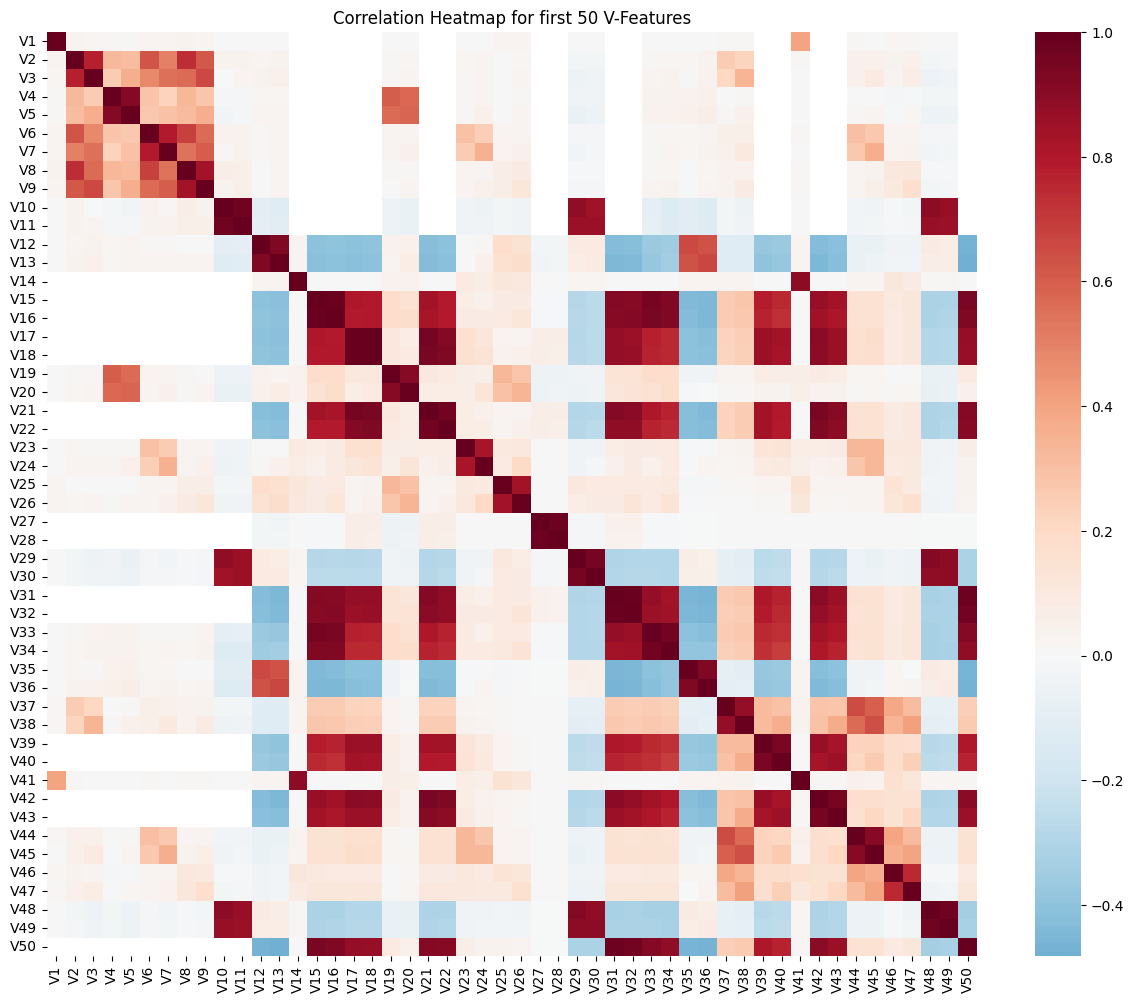

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

v_cols = [c for c in X_train.columns if c.startswith('V')][:50]
v_subset = X_train[v_cols]

corr_matrix = v_subset.corr()
plt.figure(figsize=(15, 12))

sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlation Heatmap for first 50 V-Features')
plt.show()

In [36]:
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationSelection(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.features_to_drop = []

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        self.to_drop = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.to_drop)

# Training

In [37]:
mlflow.set_experiment("Logistic-regression")

<Experiment: artifact_location='mlflow-artifacts:/18f0f9f782c84d7399e5099ab27530d0', creation_time=1777794719236, experiment_id='0', last_update_time=1777794719236, lifecycle_stage='active', name='Logistic-regression', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [60]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, average_precision_score

def calculate_fraud_metrics(y_true, y_pred, y_probs):
    return {
        "auc_roc": roc_auc_score(y_true, y_probs),
        "pr_auc": average_precision_score(y_true, y_probs), # მნიშვნელოვანია დისბალანსისას
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }



In [61]:
import mlflow

def run_experiment(pipeline, run_name, params=None):
    with mlflow.start_run(run_name=run_name):
        if params:
            mlflow.log_params(params)
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        y_probs = pipeline.predict_proba(X_test)[:, 1]
        
        metrics = calculate_fraud_metrics(y_test, y_pred, y_probs)
        

        mlflow.log_metrics(metrics)
        
        mlflow.sklearn.log_model(pipeline, "model")
        
        print(f"Run '{run_name}' completed. AUC: {metrics['auc_roc']:.4f}")

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# შევქმნათ Logistic Regression პაიპლაინი
log_reg_pipeline_base = Pipeline([
    ('drop_nan', DropMissingFeatures(threshold=0.9)),
    ('cat_enc', CategoricalEncoder()),             
    ('imputer', SimpleImputer(strategy='median')),   # NaN-ების შევსება (LR ვერ მუშაობს NaN-ზე)
    ('scaler', StandardScaler()),                   # მასშტაბირება (LR-ისთვის აუცილებელია!)
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

X_train_copy = X_train.copy()
y_train_copy=y_train.copy()
# 2. მოდელის გაწვრთნა
log_reg_pipeline_base.fit(X_train_copy, y_train_copy)

# 3. პროგნოზი
y_pred_prob = log_reg_pipeline_base.predict_proba(X_test)[:, 1]

In [62]:
lr_params = {
    "model_type": "LogisticRegression",
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 1000
}

# 2. გაუშვი ექსპერიმენტი
#run_experiment(log_reg_pipeline_base, "LR_Baseline", params=lr_params)

2026/05/03 09:20:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 09:20:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 'LR_Baseline' completed. AUC: 0.8649
🏃 View run LR_Baseline at: https://dagshub.com/mkekn23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/e5e76f9f1bd24c1890d981bb77b090cf
🧪 View experiment at: https://dagshub.com/mkekn23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [64]:
import gc
gc.collect()

1980

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


log_reg_pipeline_enhanced = Pipeline([
    ('time_enc', TimeFeaturesEncoder()),         
    ('aggr', GroupAggregationTransformer()),      
    ('drop_nan', DropMissingFeatures(threshold=0.9)),
    ('cat_enc', CategoricalEncoder()),             
    ('imputer', SimpleImputer(strategy='median')),   # NaN-ების შევსება (LR ვერ მუშაობს NaN-ზე)
    ('scaler', StandardScaler()),                   # მასშტაბირება (LR-ისთვის აუცილებელია!)
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

X_train_copy = X_train.copy()
y_train_copy=y_train.copy()
log_reg_pipeline_enhanced.fit(X_train_copy, y_train_copy)

y_pred_prob = log_reg_pipeline_enhanced.predict_proba(X_test)[:, 1]

In [73]:
lr_params = {
    "model_type": "LogisticRegression",
    "C": 1.0,
    "class_weight": "balanced",
    "max_iter": 1000
}


#run_experiment(log_reg_pipeline_enhanced, "LR_with_new_features", params=lr_params)

2026/05/03 09:35:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 09:35:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run 'LR_with_new_features' completed. AUC: 0.8652
🏃 View run LR_with_new_features at: https://dagshub.com/mkekn23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/3b014e3f38ea4666ad5fe3942aff7cf6
🧪 View experiment at: https://dagshub.com/mkekn23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
